<a href="https://colab.research.google.com/github/StudentbcuAKR/Cybersecurity/blob/main/part2assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (457044, 84)
Sample shape: (50000, 84)
Detected label column: Label
Shape after cleaning: (49990, 80)
Classes: ['Benign', 'Bot', 'DDoS', 'Dos', 'Prob']
Feature shape: (49990, 79)
Training: Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training: Decision Tree
Training: Random Forest
Training: XGBoost
                 Model  Accuracy  Precision    Recall  F1 Score
3              XGBoost  0.887878   0.905918  0.887878  0.885551
2        Random Forest  0.862573   0.860747  0.862573  0.861635
1        Decision Tree  0.857872   0.856985  0.857872  0.857421
0  Logistic Regression  0.709942   0.771109  0.709942  0.698137


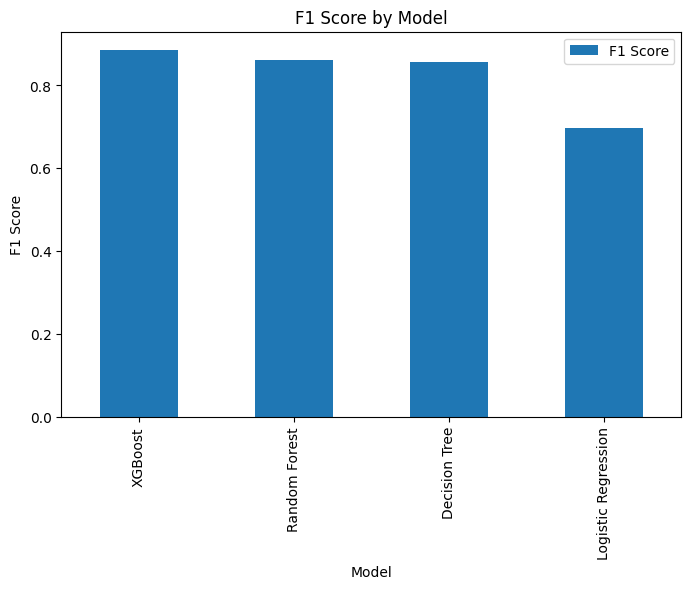

In [ ]:
# This Installs the XGBoost
!pip install -q xgboost

# This Imports the libraries
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Mount Google Drive
drive.mount('/content/drive')

# Read dataset
file_path = "/content/drive/MyDrive/ASEADOS_SDN_IoT.csv"
df = pd.read_csv(file_path)

print("Original shape:", df.shape)

# Use a smaller sample to stop RAM crashing
df = df.sample(n=50000, random_state=42)

print("Sample shape:", df.shape)

# Try to detect label column
possible_labels = ["Label", "label", "Attack", "Attack Type", "Category", "Class", "class"]
label_col = None

for col in possible_labels:
    if col in df.columns:
        label_col = col
        break

print("Detected label column:", label_col)

# Clean data
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Drop columns that often waste memory
drop_cols = [col for col in ["Flow ID", "Src IP", "Dst IP", "Timestamp"] if col in df.columns]
df.drop(columns=drop_cols, inplace=True, errors="ignore")

print("Shape after cleaning:", df.shape)

# Split features and label
X = df.drop(columns=[label_col]).copy()
y = df[label_col].copy()

# Convert object columns using label encoding instead of one hot encoding
for col in X.select_dtypes(include=["object"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Classes:", list(label_encoder.classes_))
print("Feature shape:", X.shape)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective="multi:softmax",
        num_class=len(np.unique(y)),
        eval_metric="mlogloss",
        random_state=42
    )
}

# Train and evaluate
results = []
trained_models = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    results.append([name, accuracy, precision, recall, f1])
    trained_models[name] = model

# Results table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
).sort_values(by="F1 Score", ascending=False)

print(results_df)

# Chart
results_df.plot(x="Model", y="F1 Score", kind="bar", figsize=(8,5))
plt.title("F1 Score by Model")
plt.ylabel("F1 Score")
plt.show()